# EDA Preliminar — Estimación de la Demanda de Car-Sharing en Milán

> **TFG · Grado en Ingeniería de Sistemas de Decisión · Juan Pablo**

Este notebook realiza la exploración y preparación de los datos necesarios para construir un modelo de estimación de la demanda horaria de car-sharing en Milán.

## Objetivo

Cruzar los registros GPS de viajes de car-sharing (2015) con la cartografía censal de Lombardía y los indicadores socioeconómicos del Censo 2011, para obtener un dataset estructurado con el que entrenar modelos de predicción de demanda por área censal.

## Fuentes de datos

| Dataset | Descripción |
|---|---|
| `milano_trips.txt` | Registros GPS de viajes de car-sharing (17/05/2015 – 01/07/2015) |
| `R03_indicadores_2011_sezioni.csv` | Indicadores socioeconómicos del Censo 2011 (región de Lombardía) |
| `R03_11_WGS84.shp` | Shapefile de secciones censales de Lombardía (WGS84) |

## Flujo del notebook

1. **Configuración del entorno** — Librerías, Google Drive y rutas
2. **Carga de datos** — Lectura de los tres datasets
3. **Preprocesamiento** — Limpieza de fechas, distancias y feature engineering temporal
4. **Integración espacial** — Spatial join viajes ↔ secciones censales + merge con indicadores
5. **EDA** — Análisis exploratorio: distribuciones temporales, espaciales y socioeconómicas
6. **Construcción del dataset ML** — Agrupación por (ACE, fecha, hora) y expansión con ceros
7. **Visualización geográfica** — Mapa interactivo de demanda media por zona

---

## 1. Configuración del Entorno

Importación de librerías, montaje de Google Drive y definición de la ruta principal del proyecto.

In [4]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import matplotlib.colors as colors
import numpy as np

# 1. (Opcional) Monta drive si quieres que el repo se guarde ahí

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
main_path='/content/drive/MyDrive/GISD/CURSO4/TFG'

## 2. Carga de Datos

Lectura de los tres conjuntos de datos principales:
- **Viajes GPS** (`milano_trips.txt`): 151.330 viajes con coordenadas de origen/destino, timestamps y nivel de combustible.
- **Indicadores censales** (`R03_indicadores_2011_sezioni.csv`): variables socioeconómicas por sección censal.
- **Geometrías** (`R03_11_WGS84.shp`): polígonos de las secciones censales, filtrados al municipio de Milán (`PRO_COM = 15146`).

In [ ]:

indicadores = pd.read_csv('/content/drive/MyDrive/GISD/CURSO4/TFG/dati-cpa_2011/Sezioni_di_Censimento/R03_indicatori_2011_sezioni.csv',
                          sep=';',
                          engine='python',
                          encoding='iso-8859-1')
milano_trips= pd.read_csv(f'{main_path}/cs_datasets/milano_trips.txt', sep=None, engine='python', header=0, encoding='utf-8')
milano_distritos = gpd.read_file('/content/drive/MyDrive/GISD/CURSO4/TFG/mapa_lombardia/R03_11_WGS84/R03_11_WGS84.shp')

In [ ]:
milano_distritos = milano_distritos[milano_distritos['PRO_COM'] == 15146].copy()

## 3. Preprocesamiento y Limpieza de los Datos de Viajes

- Normalización del formato de fechas (eliminación del timezone y paréntesis)
- Selección de columnas relevantes, descartando campos vacíos o irrelevantes
- Limpieza de distancias (`google_distance`: conversión de `km`/`m` a float) y duraciones (`traveltime`)
- Filtrado de viajes con distancia ≤ 0.1 km (ruidos/errores)
- Extracción de variables temporales: hora, día de la semana, mes
- Construcción de la geometría de punto de origen (`s_coord` → `Point`)

In [ ]:
# Limpieza compartida entre frameworks (XGBoost + LSTM)
# El detalle de los criterios y umbrales esta en trip_cleaning.py
import sys
sys.path.insert(0, ".")
from trip_cleaning import clean_trips, parse_date_local

# 1. Cleaning unificado (filtra outliers de distancia, duracion y geografia)
milano_trips, stats = clean_trips(milano_trips, "milano")
print(f"\nResumen del cleaning Milan: {stats}")

# 2. Parseo de fechas en hora local (XGBoost trabaja en hora local)
milano_trips["s_date"] = milano_trips["s_date"].apply(parse_date_local)
milano_trips["e_date"] = milano_trips["e_date"].apply(parse_date_local)
milano_trips = milano_trips.dropna(subset=["s_date"])

# 3. Seleccion de columnas (incluye las derivadas que produce clean_trips)
columns_to_keep = [
    "vin", "traveltime", "google_time", "google_distance",
    "s_date", "s_coord", "s_fuel", "e_date", "e_coord", "e_fuel",
    "dist_km", "dur_min", "lat", "lon",
]
milano_trips = milano_trips[columns_to_keep].copy()

# 4. Feature engineering temporal
milano_trips["hour"]        = milano_trips["s_date"].dt.hour
milano_trips["day_name"]    = milano_trips["s_date"].dt.day_name()
milano_trips["day_of_week"] = milano_trips["s_date"].dt.dayofweek
milano_trips["month"]       = milano_trips["s_date"].dt.month

# 5. Geometria a partir de lat/lon ya parseadas (no hace falta re-split)
from shapely.geometry import Point
milano_trips["geometry"] = milano_trips.apply(
    lambda r: Point(r["lon"], r["lat"]), axis=1
)
gdf_trips = gpd.GeoDataFrame(milano_trips, geometry="geometry", crs="EPSG:4326")


In [ ]:
# Celda fusionada con la anterior (limpieza centralizada en trip_cleaning.clean_trips). Mantenida vacia para no desplazar los indices del notebook.

## 4. Integración Espacial con los Datos del Censo

### 4.1 Spatial Join — Viajes ↔ Secciones Censales
Ambas capas se reproyectan a **EPSG:4326** y se realiza un `sjoin` con predicado `within` para asignar a cada viaje la sección censal de origen.

### 4.2 Merge con Indicadores Socioeconómicos
Se fusiona el resultado del spatial join con los indicadores del Censo 2011 usando la clave `SEZ2011`, generando el dataframe `df_entrenamiento`.

In [ ]:
# Forzamos a que ambos tengan exactamente el mismo sistema
gdf_trips = gdf_trips.to_crs(epsg=4326)
milano_distritos = milano_distritos.to_crs(epsg=4326)
trips_final = gpd.sjoin(gdf_trips, milano_distritos, how="left", predicate="within")

In [ ]:
df_entrenamiento = trips_final.merge(indicadores, on='SEZ2011', how='inner')

## 5. Análisis Exploratorio de los Datos (EDA)

Visualizaciones para entender los patrones de uso del servicio y validar la calidad del dataset integrado.

| Gráfico | Pregunta de investigación |
|---|---|
| **A. Distribución temporal** | ¿En qué horas y días se usa más el servicio? |
| **B. Distancias y duraciones** | ¿Cuál es el viaje típico? |
| **C. Demanda vs. indicadores** | ¿Los barrios con más estudiantes hacen viajes más cortos? |
| **D. Calidad del dato** | ¿Hay nulos en las variables clave del modelo? |

Total de viajes en el dataset: 151330


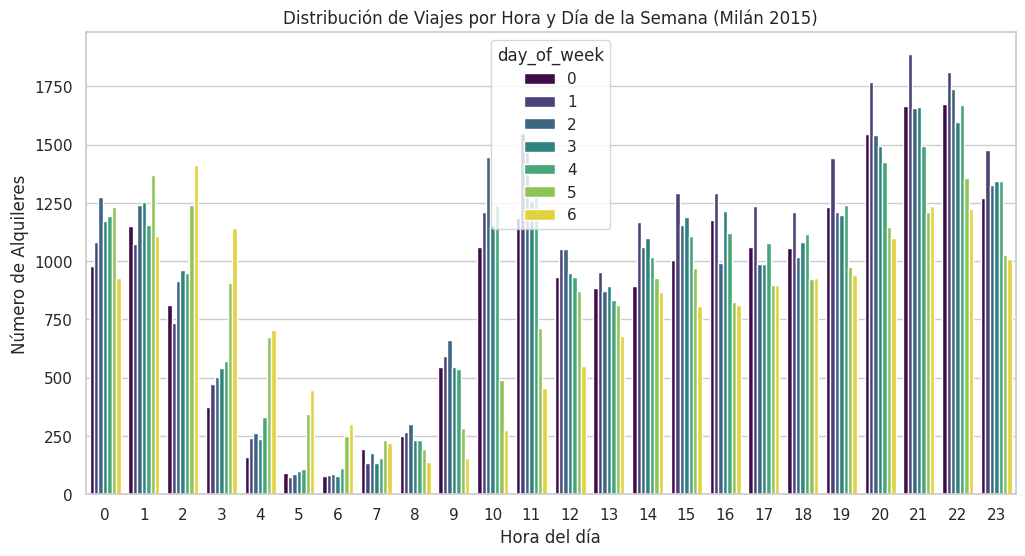

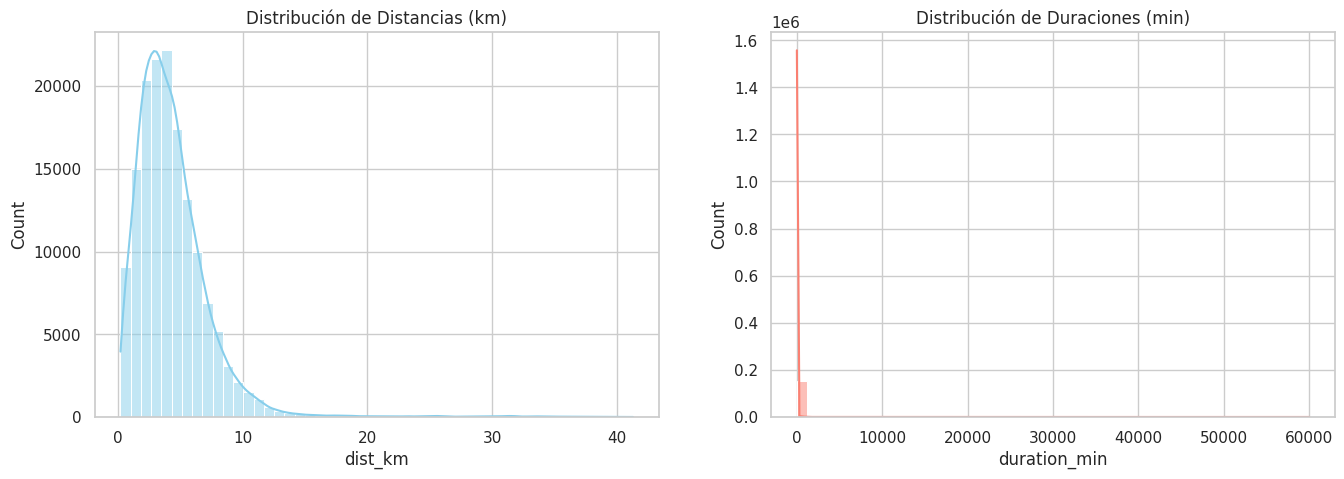

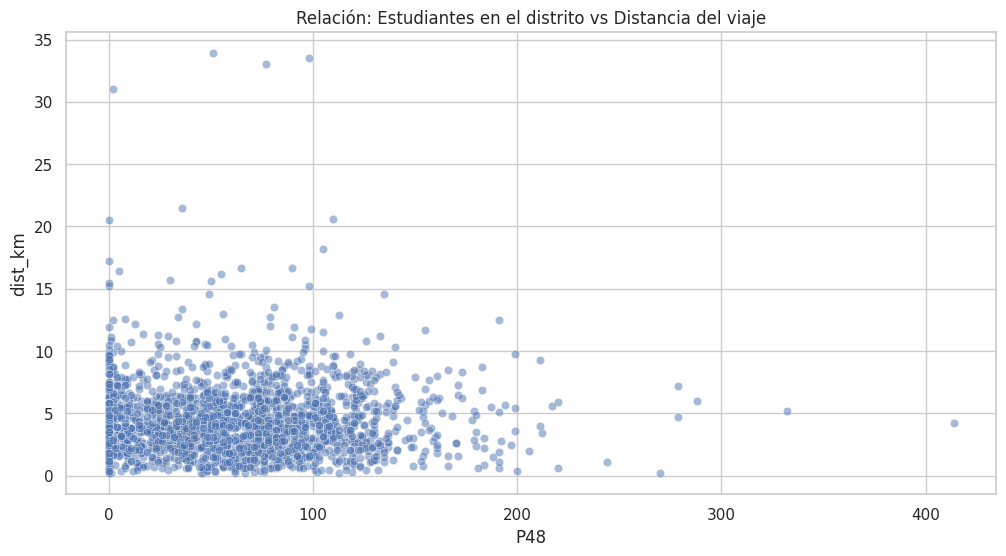


Chequeo de nulos en indicadores:
P1         0
P48        0
E3         0
SEZ2011    0
dtype: int64


In [ ]:
# Configuración estética para tu informe de TFG
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

print(f"Total de viajes en el dataset: {len(df_entrenamiento)}")

# A. Distribución Temporal (¿Cuándo se usa más el servicio?)
plt.figure()
sns.countplot(data=df_entrenamiento, x='hour', hue='day_of_week', palette='viridis')
plt.title('Distribución de Viajes por Hora y Día de la Semana (Milán 2015)')
plt.xlabel('Hora del día')
plt.ylabel('Número de Alquileres')
plt.show()

# B. Análisis de Distancias y Duración
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df_entrenamiento['dist_km'], bins=50, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Distribución de Distancias (km)')
sns.histplot(df_entrenamiento['duration_min'], bins=50, kde=True, ax=ax2, color='salmon')
ax2.set_title('Distribución de Duraciones (min)')
plt.show()

# C. Relación Demanda vs Indicadores (Correlación rápida)
# Vamos a ver si los barrios con más estudiantes (P48) tienen viajes más cortos
plt.figure()
sns.scatterplot(data=df_entrenamiento.sample(2000), x='P48', y='dist_km', alpha=0.5)
plt.title('Relación: Estudiantes en el distrito vs Distancia del viaje')
plt.show()

# D. Chequeo de Calidad: Valores nulos en indicadores críticos
critical_cols = ['P1', 'P48', 'E3', 'SEZ2011']
print("\nChequeo de nulos en indicadores:")
print(df_entrenamiento[critical_cols].isnull().sum())

### 5.1 Cobertura Espacial del Dataset

¿Qué fracción de las áreas censales de Milán tiene al menos un viaje registrado?

In [ ]:
n_secciones_con_viajes = df_entrenamiento['ACE_x'].nunique()
print(f"Tu modelo va a aprender de {n_secciones_con_viajes} áreras censales diferentes de Milán.")
# Contar cuántas secciones pertenecen al municipio de Milán
secciones_milan = milano_distritos[milano_distritos['PRO_COM'] == 15146]['ACE_x'].nunique()
print(f"Áreas censales totales en el mapa de Milán: {secciones_milan}")

# Ver cuántas de esas secciones tienen viajes en tu dataset
viajes_milan = df_entrenamiento[df_entrenamiento['PRO_COM'] == 15146]
# Calcular viajes por sección
viajes_por_sez = df_entrenamiento.groupby('ACE_x').size()

print("Estadísticas de viajes por área censal:")
print(viajes_por_sez.describe())

# Ver el Top 10 de secciones con más demanda
print("\nTop 10 áreas censales con más demanda:")
print(viajes_por_sez.sort_values(ascending=False).head(10))

Tu modelo va a aprender de 5565 micro-zonas diferentes de Milán.
Secciones totales en el mapa de Milán: 6085
Secciones de Milán con al menos un viaje: 5565
Estadísticas de viajes por sección:
count    5565.000000
mean       27.193172
std        35.467164
min         1.000000
25%         7.000000
50%        17.000000
75%        35.000000
max       778.000000
dtype: float64

Top 10 secciones con más demanda:
SEZ2011
1.514600e+11    778
1.514600e+11    541
1.514600e+11    466
1.514600e+11    395
1.514600e+11    350
1.514600e+11    342
1.514600e+11    326
1.514600e+11    323
1.514600e+11    303
1.514600e+11    302
dtype: int64


## 6. Construcción del Dataset de Machine Learning

### 6.1 Agrupamiento por Área Censal, Fecha y Hora

Los registros GPS se agregan por `(ACE, fecha, hora)` para obtener la **demanda horaria** en cada zona.  
Periodo cubierto: **17/05/2015 – 01/07/2015**.

Variables del dataset resultante:

| Variable | Tipo | Descripción |
|---|---|---|
| `ACE` | ID | Área censal de Milán |
| `date_only` | Fecha | Día del viaje |
| `hour` | Temporal | Hora del día (0–23) |
| `target_demanda` | **Objetivo** | Número de alquileres en esa ACE-hora |
| `population_resident` | Censal | Población total residente (`P1`) |
| `student_count` | Censal | Estudiantes residentes (`P48`) |
| `outbound_commuters` | Censal | Personas que trabajan fuera del municipio (`P52`) |
| `employed_resident` | Censal | Personas empleadas residentes (`E3`) |
| `Shape_Area` | Geométrica | Área de la zona (m²) |
| `demand_density` | Derivada | Alquileres por km² |
| `pop_density` | Derivada | Habitantes por km² |
| `day_of_week` | Temporal | Día de la semana (0=lunes, 6=domingo) |
| `month` | Temporal | Mes |

In [ ]:
df_entrenamiento['date_only'] = pd.to_datetime(df_entrenamiento['s_date']).dt.date
dataset_ml = df_entrenamiento.groupby(['ACE_x', 'date_only', 'hour']).agg({
    'vin': 'count',            # Variable objetivo: número de alquileres (Demanda)
    'P1': 'sum',             # Población total residente
    'P48': 'sum',            # Estudiantes residentes
    'P52': 'sum',            # Personas que trabajan fuera del municipio
    'E3': 'sum',             # Personas empleadas
    'Shape_Area': 'sum',     # Área del distrito para normalizar
    'day_of_week': 'first',    # Lunes=0, Domingo=6
    'month': 'first'           # Estacionalidad mensual
}).reset_index()

# Renombrar la columna del conteo a nuestra variable 'y'
dataset_ml.rename(columns={'ACE_x':'ACE','vin': 'target_demanda', 'P1':'population_resident', 'P48':'student_count','P52':'outbound_commuters','E3':'employed_resident'}, inplace=True)

# Feature Engineering extra: Densidad de demanda (fundamental para comparar distritos de distinto tamaño)
dataset_ml['demand_density'] = dataset_ml['target_demanda'] / (dataset_ml['Shape_Area'] / 1000000)
dataset_ml['pop_density'] = dataset_ml['population_resident'] / (dataset_ml['Shape_Area'] / 1000000)
# # # Visualizar el resultado
print(f"Dimensiones del dataset de entrenamiento: {dataset_ml.shape}")


Dimensiones del dataset de entrenamiento: (54985, 13)


In [ ]:
dataset_ml.sort_values(by=['date_only','hour']).head(10)

,ACE,date_only,hour,target_demanda,population_resident,student_count,outbound_commuters,employed_resident,Shape_Area,day_of_week,month,demand_density,pop_density
123,1.0,2015-05-17,2,10,1461,421,2,88,132867.850152,6,5,75.262752,10995.888007
1034,2.0,2015-05-17,2,15,1909,489,8,95,393344.347063,6,5,38.134525,4853.253935
1952,3.0,2015-05-17,2,10,2171,582,9,70,168244.749805,6,5,59.437219,12903.820194
2849,4.0,2015-05-17,2,3,593,174,2,18,57334.115649,6,5,52.324867,10342.882127
3677,5.0,2015-05-17,2,7,649,169,1,28,265429.745449,6,5,26.372327,2445.091446
4635,6.0,2015-05-17,2,5,600,204,2,28,364906.636046,6,5,13.702135,1644.256203
5524,7.0,2015-05-17,2,7,797,238,3,30,175974.423224,6,5,39.778508,4529.067267
6445,8.0,2015-05-17,2,13,2426,715,7,105,261475.955884,6,5,49.717765,9278.099746
7381,9.0,2015-05-17,2,5,1166,332,3,56,62107.662547,6,5,80.505364,18773.850958
8247,10.0,2015-05-17,2,8,1103,310,0,40,234161.212521,6,5,34.164497,4710.429999


### 6.2 Expansión Temporal — Relleno de Ceros

El dataset anterior sólo contiene filas donde **hubo al menos un alquiler**. Para entrenar correctamente el modelo necesitamos el producto cartesiano completo `ACE × día × hora`, rellenando con `target_demanda = 0` donde no hubo actividad.

Las variables del censo (constantes por ACE) se propagan con `ffill/bfill` por grupo.

In [ ]:
# 1. Definir el rango completo de tiempo que hay en tus datos
start_date = dataset_ml['date_only'].min()
end_date = dataset_ml['date_only'].max()
all_dates = pd.date_range(start_date, end_date).date
all_hours = np.arange(24)
all_sections = dataset_ml['ACE'].unique()

# 2. Crear un DataFrame con TODAS las combinaciones posibles (Cartesian Product)
# Esto genera el esqueleto completo: Seccion x Dia x Hora
index_grid = pd.MultiIndex.from_product(
    [all_sections, all_dates, all_hours],
    names=['ACE', 'date_only', 'hour']
).to_frame(index=False)

# 3. Cruzar el esqueleto con tus datos reales de demanda
dataset_full = pd.merge(index_grid, dataset_ml, on=['ACE', 'date_only', 'hour'], how='left')

# 4. Rellenar la demanda con 0 en los huecos (donde no hubo viajes)
dataset_full['target_demanda'] = dataset_full['target_demanda'].fillna(0)
dataset_full['demand_density'] = dataset_full['demand_density'].fillna(0)

# 5. Rellenar los datos del censo (que son constantes para cada ACE)
# Usamos groupby + ffill/bfill para que cada seccion tenga su poblacion, area, etc. siempre
census_cols = ['population_resident', 'student_count', 'outbound_commuters', 'employed_resident', 'Shape_Area', 'pop_density']
for col in census_cols:
    dataset_full[col] = dataset_full.groupby('ACE')[col].transform(lambda x: x.ffill().bfill())

# 6. Recalcular columnas temporales que se perdieron en el cruce para las filas nuevas
dataset_full['date_only'] = pd.to_datetime(dataset_full['date_only'])
dataset_full['day_of_week'] = dataset_full['date_only'].dt.dayofweek
dataset_full['month'] = dataset_full['date_only'].dt.month
dataset_full['date_only'] = dataset_full['date_only'].dt.date

# Resultado final
print(f"Dimensiones antes: {dataset_ml.shape}")
print(f"Dimensiones después (con ceros): {dataset_full.shape}")
print(f"Porcentaje de filas con demanda cero: {round((dataset_full['target_demanda'] == 0).mean() * 100, 2)}%")

Dimensiones antes: (54985, 13)
Dimensiones después (con ceros): (94944, 13)
Porcentaje de filas con demanda cero: 42.09%


## 7. Visualización Geográfica de la Demanda Media

Mapa interactivo (Folium) con las **86 zonas ACE** de Milán coloreadas por demanda media.  
Cada zona muestra un tooltip con el identificador ACE y la demanda media calculada.

In [ ]:
# 1. Preparar la geometría de las ACE (Disolver secciones en zonas)
# Usamos 'ACE_x' o 'ACE' según el nombre en tu geodataframe
milano_distritos = milano_distritos[milano_distritos['ACE']!=0]
dataset_ml = dataset_ml[dataset_ml['ACE']!=0]
ace_geoms = milano_distritos.dissolve(by='ACE').reset_index()

# 2. Calcular la demanda media por ACE desde tu dataset_ace
# (Asumiendo que ya tienes dataset_ace con la columna 'target_demanda')
avg_demand = dataset_ml.groupby('ACE')['target_demanda'].mean().reset_index()
ace_final = ace_geoms.merge(avg_demand, on='ACE', how='left').fillna(0)

# 3. Crear el mapa base centrado en Milán
m = folium.Map(location=[45.4642, 9.1900], zoom_start=12, tiles='cartodbpositron')

# 4. Generar colores aleatorios para los 86 clusters
# Usamos un mapa de colores para que se vea profesional
colormap = plt.cm.get_cmap('tab20', 86)

# 5. Añadir las zonas al mapa
folium.GeoJson(
    ace_final,
    style_function=lambda feature: {
        'fillColor': colors.to_hex(colormap(int(feature['id']) % 86)),
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.6,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['ACE', 'target_demanda'],
        aliases=['Zona ACE:', 'Demanda Media:'],
        localize=True
    )
).add_to(m)

# 6. Añadir marcadores con el número de demanda media en el centro de cada ACE
for _, row in ace_final.iterrows():
    # Obtenemos el centroide para poner el texto
    centroid = row.geometry.centroid
    folium.Marker(
        location=[centroid.y, centroid.x],
        icon=folium.DivIcon(
            html=f"""<div style="font-family: sans-serif; color: black; font-weight: bold; font-size: 10pt">
                     {row['target_demanda']:.2f}</div>"""
        )
    ).add_to(m)

m

/tmp/ipython-input-2773129237.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('tab20', 86)


---

## Apéndice — Inspección del DataFrame Integrado

Vista del dataframe `df_entrenamiento` con todas las columnas originales (viajes + censo) antes del agrupamiento.

In [113]:
df_entrenamiento

,vin,traveltime,google_time,google_distance,s_date,s_coord,s_fuel,e_date,e_coord,e_fuel,...,E23,E24,E25,E26,E27,E28,E29,E30,E31,date_only
0,WME4513341K636611,29 mins,5 mins,1.4 km,2015-05-19 11:01:43,"9.18872,45.49141,0",72,2015-05-19 11:31:26,"9.18255,45.48512,0",72,...,1,2,3,3,131,3,6,1,0,2015-05-19
1,WME4513341K636611,14 mins,12 mins,3.5 km,2015-05-17 02:00:01,"9.18195,45.46162,0",96,2015-05-17 02:14:22,"9.16616,45.48191,0",93,...,0,0,6,3,129,5,4,1,0,2015-05-17
2,WME4513341K636611,32 mins,19 mins,6.1 km,2015-05-17 02:49:20,"9.16616,45.48191,0",93,2015-05-17 03:22:08,"9.1223,45.45508,0",93,...,1,0,1,4,125,2,4,0,0,2015-05-17
3,WME4513341K636611,33 mins,12 mins,4.1 km,2015-05-18 11:46:47,"9.1223,45.45508,0",93,2015-05-18 12:20:37,"9.14877,45.47943,0",90,...,0,0,0,6,178,3,3,0,0,2015-05-18
4,WME4513341K636611,37 mins,15 mins,5.5 km,2015-05-18 20:06:31,"9.14877,45.47943,0",90,2015-05-18 20:44:24,"9.14682,45.44479,0",87,...,0,0,0,0,0,0,0,0,0,2015-05-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151325,WME4513341K828470,31 mins,5 mins,1.4 km,2015-07-01 12:55:00,"9.23662,45.47515,0",100,2015-07-01 13:26:57,"9.23682,45.47288,0",100,...,0,0,1,0,12,1,0,0,0,2015-07-01
151326,WME4513341K827801,22 mins,12 mins,3.3 km,2015-06-05 12:13:52,"9.16834,45.47064,0",51,2015-06-05 12:36:25,"9.18938,45.47544,0",51,...,0,2,2,4,142,0,8,0,0,2015-06-05
151327,WME4513341K827569,22 mins,1 min,0.3 km,2015-06-30 18:01:48,"9.18437,45.4374,0",48,2015-06-30 18:24:24,"9.18347,45.43669,0",45,...,7,2,1,3,124,2,12,0,0,2015-06-30
151328,WME4513341K827784,56 mins,16 mins,4.1 km,2015-05-23 22:05:02,"9.19184,45.47051,0",72,2015-05-23 23:01:23,"9.16935,45.45164,0",69,...,2,7,9,7,285,16,9,0,0,2015-05-23


## 8. Modelado Preliminar — XGBoost

Primeras pruebas con **XGBoost** para estimar la demanda horaria por área censal.

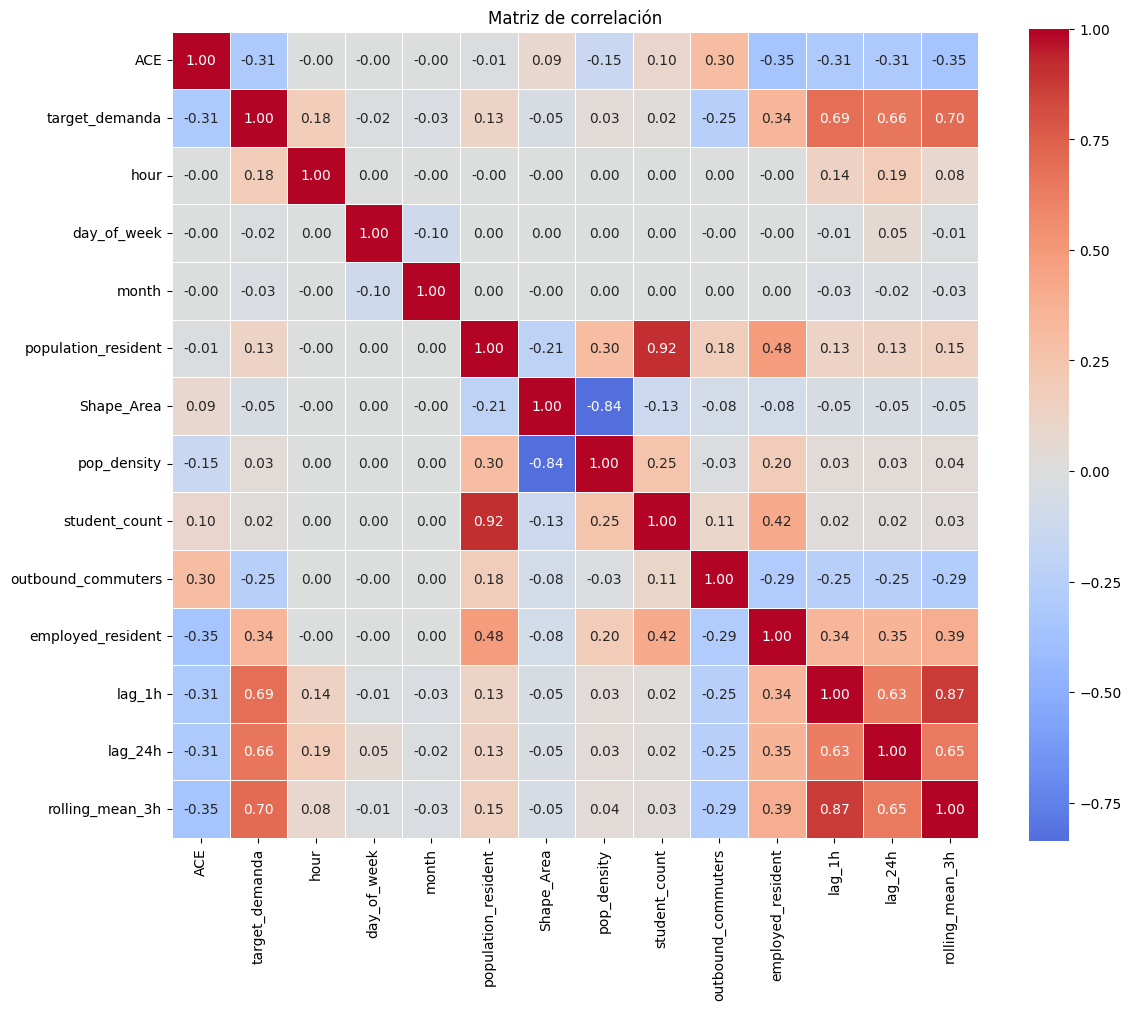

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'ACE','target_demanda', 'hour', 'day_of_week', 'month',
    'population_resident', 'Shape_Area', 'pop_density',
    'student_count', 'outbound_commuters', 'employed_resident',
    'lag_1h', 'lag_24h', 'rolling_mean_3h'
]

corr = dataset_ml[cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

### 8.1 Regresión

Predicción directa de `target_demanda` usando variables censales y temporales. Se evalúa con MAE, RMSE y R² sobre una partición temporal.

In [30]:
dataset_ml = pd.read_csv('dataset_ml.csv')

Entrenando con datos hasta: 2015-06-24 00:00:00
Testeando con la semana del: 2015-06-25 00:00:00 al 2015-07-01 00:00:00

--- Resultados del Modelo ---
MAE: 0.9247 (Error medio en número de viajes)
RMSE: 1.4663
R2 Score: 0.5660


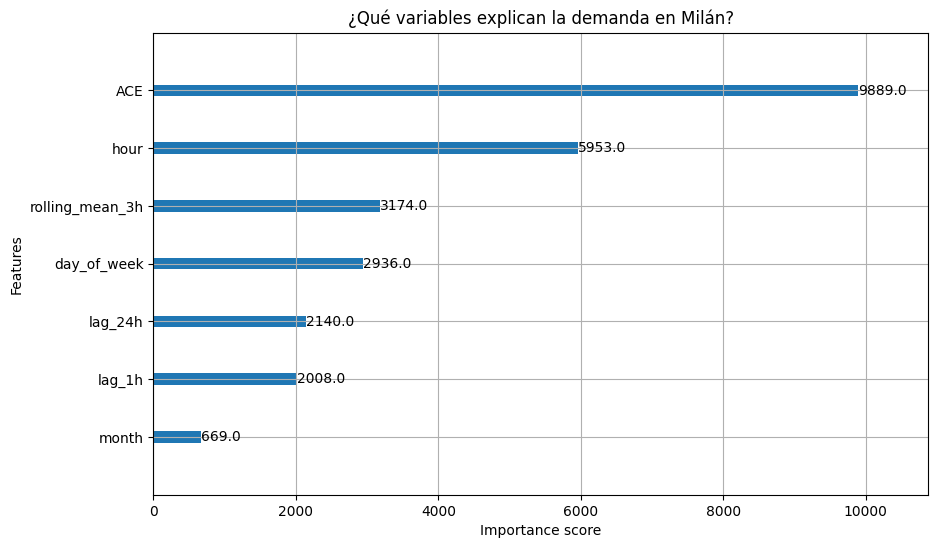

In [31]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dataset_ml['ACE'] = dataset_ml['ACE'].astype(int).astype('category')

# features = [
#     'ACE',                  # Identificador de zona (como categoría)
#     'hour', 'day_of_week', 'month',
#     'population_resident',   # Volumen total de gente
#     'Shape_Area',            # Tamaño físico de la zona
#     'pop_density',           # Relación entre ambas
#     'student_count', 'outbound_commuters', 'employed_resident',
#     'lag_1h', 'lag_24h', 'rolling_mean_3h'
# ]
features = [
    'ACE',                  # Identificador de zona (como categoría)
    'hour', 'day_of_week', 'month',
    'lag_1h', 'lag_24h', 'rolling_mean_3h'
]
target = 'target_demanda'
dataset_ml['date_only'] = pd.to_datetime(dataset_ml['date_only'])
# 2. SPLIT TEMPORAL AUTOMÁTICO
# Ordenamos por fecha para no mezclar pasado y futuro
dataset_ml = dataset_ml.sort_values(['date_only', 'hour'])

# Definimos el punto de corte (ej: dejar los últimos 7 días para test)
fecha_max = dataset_ml['date_only'].max()
fecha_corte = fecha_max - pd.Timedelta(days=7)

train = dataset_ml[dataset_ml['date_only'] <= fecha_corte]
test = dataset_ml[dataset_ml['date_only'] > fecha_corte]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Entrenando con datos hasta: {fecha_corte}")
print(f"Testeando con la semana del: {fecha_corte + pd.Timedelta(days=1)} al {fecha_max}")

# 3. CONFIGURACIÓN Y ENTRENAMIENTO DEL MODELO (XGBoost)
# Usamos 'reg:tweedie' porque gestiona de forma nativa datasets con muchísimos ceros
model_xgb = xgb.XGBRegressor(
    objective='reg:tweedie',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    enable_categorical = True
)

model_xgb.fit(X_train, y_train)

# 4. PREDICCIÓN Y MÉTRICAS
preds = model_xgb.predict(X_test)

# Como la demanda no puede ser negativa ni decimal en la realidad, redondeamos y clipamos
preds_final = np.maximum(0, np.round(preds))

mae = mean_absolute_error(y_test, preds_final)
rmse = np.sqrt(mean_squared_error(y_test, preds_final))
r2 = r2_score(y_test, preds_final)

print(f"\n--- Resultados del Modelo ---")
print(f"MAE: {mae:.4f} (Error medio en número de viajes)")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

# 5. VISUALIZACIÓN DE IMPORTANCIA DE VARIABLES
plt.figure(figsize=(10, 6))
xgb.plot_importance(model_xgb, importance_type='weight', ax=plt.gca())
plt.title('¿Qué variables explican la demanda en Milán?')
plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
tscv = TimeSeriesSplit(n_splits=5)
dataset_ml = dataset_ml.sort_values(['date_only', 'hour'])
X = dataset_ml[features]
y = dataset_ml['target_demanda']

scores = cross_val_score(
    model_xgb, X, y,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

print(f"MAE medio: {-scores.mean():.4f} ± {scores.std():.4f}")

MAE medio: 0.9886 ± 0.0390


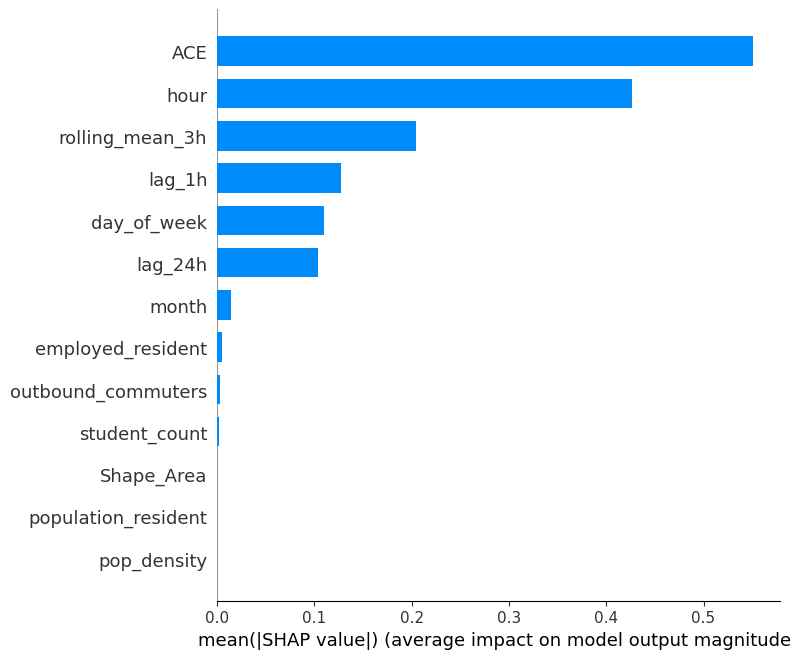

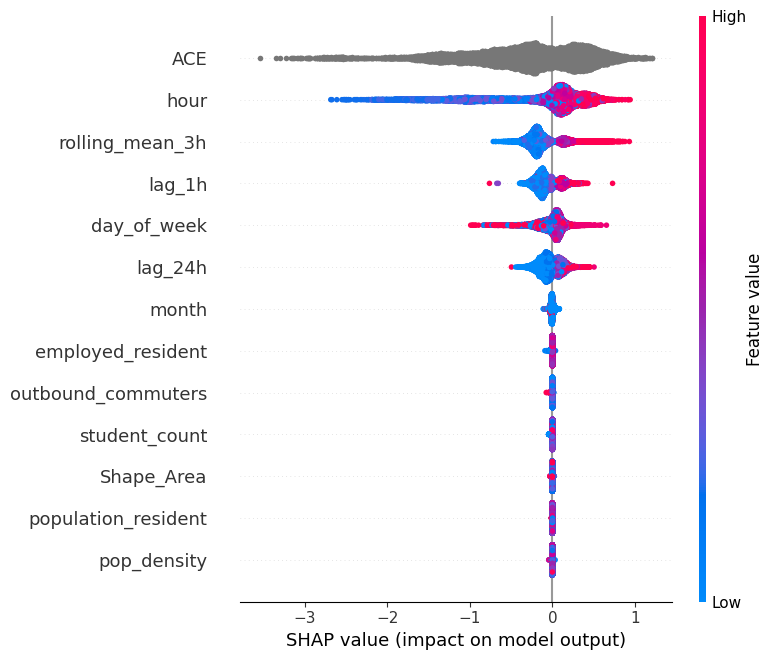

In [ ]:
import shap

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

# Importancia global (más honesta que weight)
shap.summary_plot(shap_values, X_test, plot_type='bar')

# Impacto detallado por variable
shap.summary_plot(shap_values, X_test)

### 8.2 Clasificación

Discretización de la demanda en 3 clases (`sin demanda`, `baja`, `alta`) y entrenamiento con **XGBClassifier** con pesos de clase para compensar el desbalanceo.

In [34]:
# ── Bins 3 clases ─────────────────────────────────────────────
bins_final = [-np.inf, 0, 3, np.inf]
labels     = ['sin_demanda', 'moderada', 'alta']

train['target_clase'] = pd.cut(train['target_demanda'], bins=bins_final, labels=labels)
test['target_clase']  = pd.cut(test['target_demanda'],  bins=bins_final, labels=labels)

clase_map = {label: i for i, label in enumerate(labels)}
train['target_clase_num'] = train['target_clase'].map(clase_map)
test['target_clase_num']  = test['target_clase'].map(clase_map)

print(train['target_clase'].value_counts().sort_index())

# ── Lags sobre la clase numérica ──────────────────────────────
dataset_ml['target_clase_num'] = pd.cut(
    dataset_ml['target_demanda'], bins=bins_final, labels=False
)

dataset_ml['lag_1h']  = dataset_ml.groupby('ACE')['target_demanda'].shift(1)
dataset_ml['lag_24h'] = dataset_ml.groupby('ACE')['target_demanda'].shift(24)
dataset_ml['rolling_mean_3h'] = (
    dataset_ml.groupby('ACE')['target_demanda']
    .shift(1).rolling(3).mean()
)

features_clf = [
    'ACE',
    'hour', 'day_of_week', 'month',
    'lag_1h', 'lag_24h', 'rolling_mean_3h',      # ← valor crudo
    'population_resident', 'Shape_Area', 'pop_density',
    'student_count', 'outbound_commuters', 'employed_resident'  # ← añadir
]# ← contexto zona


# ── Re-split con nuevos features ──────────────────────────────
train_clf = dataset_ml[dataset_ml['date_only'] <= fecha_corte].dropna(subset=features_clf)
test_clf  = dataset_ml[dataset_ml['date_only'] > fecha_corte].dropna(subset=features_clf)

X_train = train_clf[features_clf]
y_train = train_clf['target_clase_num'].astype(int)
X_test  = test_clf[features_clf]
y_test  = test_clf['target_clase_num'].astype(int)

target_clase
sin_demanda    33251
moderada       36164
alta           11081
Name: count, dtype: int64


/tmp/ipykernel_28583/1996896599.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['target_clase'] = pd.cut(train['target_demanda'], bins=bins_final, labels=labels)
/tmp/ipykernel_28583/1996896599.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['target_clase']  = pd.cut(test['target_demanda'],  bins=bins_final, labels=labels)
/tmp/ipykernel_28583/1996896599.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

[0]	validation_0-mlogloss:1.07971
[50]	validation_0-mlogloss:0.82256
[100]	validation_0-mlogloss:0.80611
[150]	validation_0-mlogloss:0.80292
[189]	validation_0-mlogloss:0.80304
[0]	validation_0-mlogloss:0.95841
[50]	validation_0-mlogloss:0.75153
[100]	validation_0-mlogloss:0.74408
[121]	validation_0-mlogloss:0.74529
Accuracy:    0.6322
F1 Weighted: 0.6333
F1 Macro:    0.6202
              precision    recall  f1-score   support

 sin_demanda       0.67      0.52      0.58      1664
    moderada       0.56      0.68      0.61      6076
        alta       0.71      0.62      0.66      6708

    accuracy                           0.63     14448
   macro avg       0.65      0.60      0.62     14448
weighted avg       0.64      0.63      0.63     14448



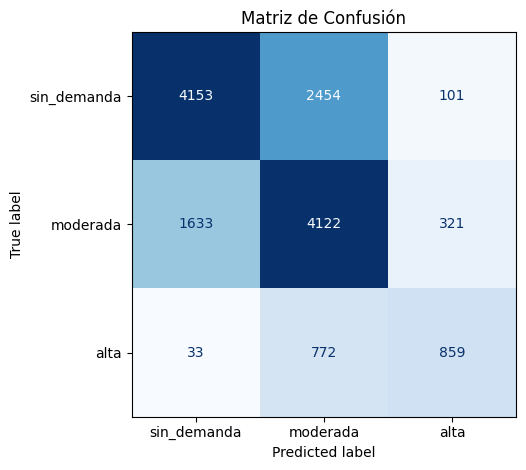

In [35]:
from sklearn.utils.class_weight import compute_sample_weight

model_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    enable_categorical=True,
    eval_metric='mlogloss',
    early_stopping_rounds=30
)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model_clf.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=50
)
model_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# ── Métricas ──────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds        = model_clf.predict(X_test)
preds_labels = [labels[i] for i in preds]
y_test_labels = [labels[i] for i in y_test]

print(f"Accuracy:    {accuracy_score(y_test, preds):.4f}")
print(f"F1 Weighted: {f1_score(y_test, preds, average='weighted'):.4f}")
print(f"F1 Macro:    {f1_score(y_test, preds, average='macro'):.4f}")
print(classification_report(y_test_labels, preds_labels, target_names=labels))

cm = confusion_matrix(y_test_labels, preds_labels, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()